In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from trainer import standard_trainer
from sensorium.utility.scores import get_correlations

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from autoencoder import Autoenc

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]


dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": True, 
    "autoencoder": None,
}

trainer_config = {
    'max_iter': 200,
    'verbose': False,
    'lr_decay_steps': 4,
    'avg_loss': False,
    'lr_init': 0.009,
    'device': device, 
}

In [4]:
model_seeds = [0, 1, 2]

In [ ]:
for seed in model_seeds:
    model = stacked_core_full_gauss_readout(dataloaders, seed, **model_config)

    standard_trainer(model, dataloaders, seed=seed, **trainer_config)

    torch.save(model.state_dict(), f'checkpoints/base/model_weights{seed}.pth')

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Epoch 65: 100%|██████████| 252/252 [00:39<00:00,  6.40it/s]


In [5]:
def train_autoenc(autoencoder, features):
    criterion = torch.nn.MSELoss(reduction='sum')
    optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.3, patience=100)

    epochs = int(1e15)
    min_lr = 1e-5

    for epoch in range(epochs):
        recon = autoencoder(features)
        loss = criterion(features, recon)

        optim.zero_grad()
        loss.backward()
        optim.step()
        scheduler.step(loss.item())
        if epoch % 100 == 0:
            lr = optim.param_groups[0]['lr']
            if lr < min_lr:
                break

            print(lr, loss.item())

In [ ]:
# Autoencoder configs for different latent dims that result in less than 1% performance drop
autoencoder_configs = {
    { 'latent_dim': 32, 'hidden_dims': 512, 'hidden_layers': 3, }, 
    { 'latent_dim': 16, 'hidden_dims': 512, 'hidden_layers': 5, }, 
    { 'latent_dim': 8, 'hidden_dims': 512, 'hidden_layers': 7, }, 
    { 'latent_dim': 4, 'hidden_dims': 1024, 'hidden_layers': 7, }, 
}

In [8]:
# Train all autoencoders for each model

all_features = []

for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')

    # Extract features from all mice
    features = []
    for data_key in data_keys:
        features_single_mouse = checkpoint[f'readout.{data_key}._features']
        features_single_mouse = features_single_mouse.squeeze().permute(1, 0).detach()
        features.append(features_single_mouse)
    features = torch.cat(features)

    feature_dict = {
        'base': features.detach().cpu().numpy()
    }

    for autoencoder_config in autoencoder_configs:
        autoencoder = Autoenc(
            64, batch_norm=True, nonlinearity='GELU', **autoencoder_config
        )
        autoencoder.to(device)
        train_autoenc(autoencoder, features)
        torch.save(
            autoencoder.state_dict(), 
            f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth'
        )

        latent_features = autoencoder.encoder(features).detach().cpu().numpy()
        feature_dict[autoencoder_config['latent_dim']] = latent_features

    all_features.append(feature_dict)

    with open('all_features.pkl', 'wb') as f:
        pickle.dump(all_features, f)

0.001 788430.625
0.001 160036.96875
0.001 123042.8203125
0.001 106920.046875
0.001 100051.546875
0.001 96391.8125
0.001 94143.8359375
0.001 92407.59375
0.001 91058.3359375
0.001 90557.1484375
0.001 88898.625
0.001 87987.484375
0.001 87196.765625
0.001 86432.59375
0.001 85780.0
0.001 85055.390625
0.001 84437.625
0.001 83841.8671875
0.001 83336.4375
0.001 82804.921875
0.001 82445.59375
0.001 82374.6640625
0.001 81426.5
0.001 81185.09375
0.001 80660.484375
0.001 80210.7421875
0.001 80118.4375
0.001 79782.875
0.001 79920.515625
0.001 79111.21875
0.001 78590.109375
0.001 78343.7109375
0.001 78171.46875
0.001 77831.8125
0.001 77648.171875
0.001 77439.203125
0.001 77240.875
0.001 76862.5078125
0.001 77328.3671875
0.001 76764.4296875
0.001 76349.21875
0.001 76307.390625
0.001 75990.5546875
0.001 75924.453125
0.001 75646.9453125
0.001 75582.28125
0.001 75252.984375
0.001 75247.015625
0.001 75063.2421875
0.001 74861.3828125
0.001 75179.90625
0.001 74751.296875
0.001 74434.328125
0.001 74647.0625

In [9]:
with open('all_features.pkl', 'rb') as f:
    all_features = pickle.load(f)

In [10]:
# Performance comparison 

for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')
    model = stacked_core_full_gauss_readout(dataloaders, model_seed, **model_config)
    model.load_state_dict(checkpoint)
    model.eval()
    
    validation_score = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )
    print('base', validation_score)

    for autoencoder_config in autoencoder_configs:
        autoencoder = Autoenc(
            64, batch_norm=True, nonlinearity='GELU', **autoencoder_config
        )

        checkpoint = torch.load(f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth')
        autoencoder.load_state_dict(checkpoint)
        autoencoder.eval()

        for data_key in data_keys:
            model.readout[data_key].autoencoder = autoencoder
    
        validation_score = get_correlations(
            model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
        )
        print(autoencoder_config['latent_dim'], validation_score)
    print()

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


base 0.38690987
32 0.33295184
16 0.30431283
8 0.25953653

base 0.3818726
32 0.33465165
16 0.30258983
8 0.26316288

base 0.37960163
32 0.33200723
16 0.30257782
8 0.25568798



In [11]:
def cluster(points, n_cluster, seed):
    kmeans = KMeans(n_clusters=n_cluster, random_state=seed)
    labels = kmeans.fit_predict(points)
    
    return labels

In [12]:
# For each model type and num clusters, cluster the features from 3 different seeds and compute ARI 

n_clusters = np.unique(np.geomspace(2, 100, dtype=int, num=30))

ari_dict = {}

for model_type in all_features[0].keys():
    ari_curve = []
    for n_cluster in n_clusters:
        labels = []
        # Loops through the 3 different seeds
        for feature_dict in all_features:
            features = feature_dict[model_type]
            labels.append(cluster(features, n_cluster, 0))  # Fix clustering seed

        ari = (
            adjusted_rand_score(labels[0], labels[1])
            + adjusted_rand_score(labels[0], labels[2])
            + adjusted_rand_score(labels[1], labels[2])
        ) / 3

        ari_curve.append(ari)
    
    ari_dict[model_type] = ari_curve


with open('ari_scores.pkl', 'wb') as f:
    pickle.dump(ari_dict, f)

In [13]:
with open('ari_scores.pkl', 'rb') as f:
    ari_dict = pickle.load(f)

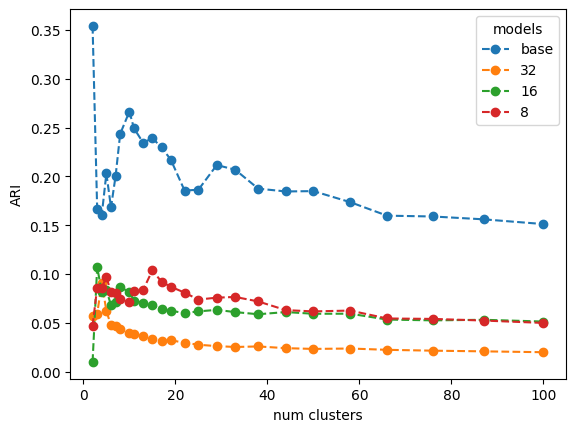

In [14]:
for model_type, ari_curve in ari_dict.items():
    plt.plot(n_clusters, ari_curve, ls='--', marker='o', label=model_type)

plt.xlabel('num clusters')
plt.ylabel('ARI')
plt.legend(title='models')
plt.show()